**Objetivo:** Detectar alterações ópticas na água da Lagoa da Conceição associadas ao rompimento da barragem de evapoinfiltração da CASAN.

In [1]:
!pip install xee

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 1.8 MB/s eta 0:00:00


In [2]:
import ee
import geemap
import xarray as xr
import xee
from xee import helpers
import shapely.geometry
import matplotlib.pyplot as plt

In [3]:
ee.Authenticate()

ee.Initialize(
    project="ee-marciobcure",
    opt_url="https://earthengine-highvolume.googleapis.com"
)

In [4]:
coords = [
    [-48.466616, -27.609322],
    [-48.466616, -27.582622],
    [-48.433228, -27.582622],
    [-48.433228, -27.609322],
    [-48.466616, -27.609322]
]

shapely_aoi = shapely.geometry.Polygon(coords)

roi = ee.Geometry.Polygon([coords])

In [5]:
def coastal_water_quality(img):

    # Máscara de nuvem
    cloud = img.select('probability')
    cloud_free = cloud.lt(20)

    # Reflectância
    sr = img.select('B.*').multiply(0.0001)

    # Máscara de água
    mndwi = sr.normalizedDifference(['B3', 'B11']).rename('mndwi')
    water = mndwi.gt(0)

    # Banda usada para turbidez
   # turbidity = sr.select('B5').rename('turbidity')

    # NDCI
    ndci = (
        sr.normalizedDifference(['B5', 'B4'])
        .rename('ndci')
    )

    return (
        ndci
        .updateMask(cloud_free)
        .updateMask(water)
        .copyProperties(img, ['system:time_start'])
    )

In [6]:
sen2 = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .linkCollection(
        ee.ImageCollection("COPERNICUS/S2_CLOUD_PROBABILITY"),
        'probability'
    )
    .filterBounds(roi)
    .filterDate("2019-01-01", "2026-05-31")
    .map(coastal_water_quality)
)

In [7]:
#target_crs = 'EPSG:3857'
target_crs = 'EPSG:31982'
#target_crs = 'EPSG:4326'

scale = 30

grid_params = helpers.fit_geometry(
    geometry=shapely_aoi,
    grid_crs=target_crs,
    grid_scale=(scale, -scale)
)

ds = xr.open_dataset(
    sen2,
    engine='ee',
    **grid_params
)

print(ds)

<xarray.Dataset> Size: 52MB
Dimensions:  (time: 1117, y: 102, x: 113)
Coordinates:
  * time     (time) datetime64[ns] 9kB 2019-01-02T13:19:55 ... 2026-05-30T13:...
  * y        (y) float64 816B 6.946e+06 6.946e+06 ... 6.943e+06 6.943e+06
  * x        (x) float64 904B 7.5e+05 7.5e+05 7.501e+05 ... 7.533e+05 7.534e+05
Data variables:
    ndci     (time, y, x) float32 51MB ...
Attributes: (12/17)
    date_range:             [1490659200000, 1647907200000]
    description:            <p>Sentinel-2 is a wide-swath, high-resolution, m...
    keywords:               ['copernicus', 'esa', 'eu', 'msi', 'reflectance',...
    period:                 0
    product_tags:           ['msi', 'sr', 'reflectance']
    provider:               European Union/ESA/Copernicus
    ...                     ...
    title:                  Sentinel-2 MSI: MultiSpectral Instrument, Level-2A
    type_name:              ImageCollection
    visualization_0_bands:  B4,B3,B2
    visualization_0_max:    3000.0
    visual

In [8]:
!pip install netcdf4


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 101.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 62.4 MB/s eta 0:00:00


In [9]:
import netCDF4

In [10]:
ds.to_netcdf('ndci_lagoa.nc')

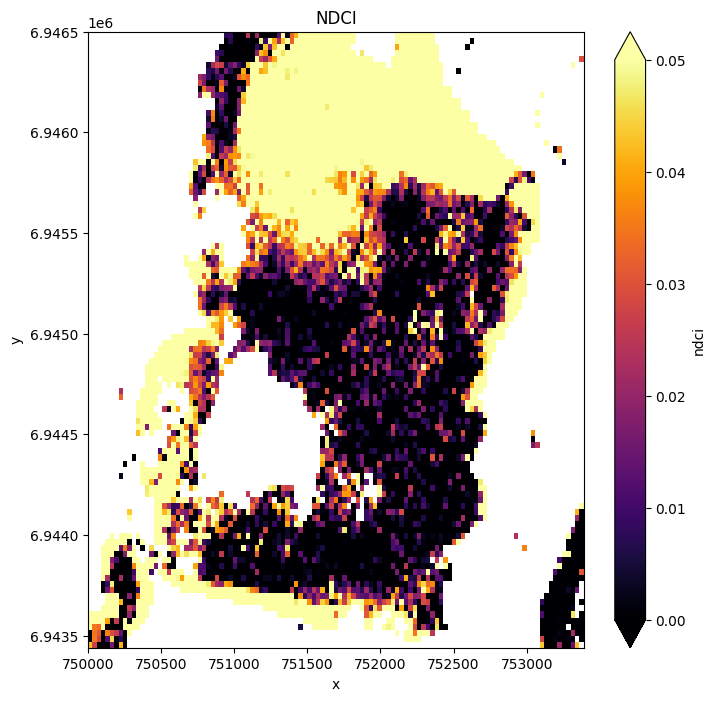

In [11]:
plt.figure(figsize=(8,8))

ds['ndci'].isel(time=15).plot(
    cmap='inferno',
    vmin=0,
    vmax=0.05
)

plt.title("NDCI")
plt.show()

In [12]:
before = ds.sel(time=slice('2019-01-01', '2021-01-24'))
after = ds.sel(time=slice('2021-01-25', '2026-05-31'))

In [13]:
baseline = before['ndci'].mean(dim='time')
baseline.max()


<xarray.DataArray 'ndci' ()> Size: 8B
array(0.5052411)
Attributes:
    id:             ndci
    data_type:      {'type': 'PixelType', 'precision': 'float', 'min': -1, 'm...
    dimensions:     [5490, 5490]
    crs:            EPSG:31982
    crs_transform:  [20, 0, 699960, 0, -20, 7000000]

In [14]:
impact = after['ndci'].mean(dim='time')
impact.min()

<xarray.DataArray 'ndci' ()> Size: 8B
array(-0.45018601)
Attributes:
    id:             ndci
    data_type:      {'type': 'PixelType', 'precision': 'float', 'min': -1, 'm...
    dimensions:     [5490, 5490]
    crs:            EPSG:31982
    crs_transform:  [20, 0, 699960, 0, -20, 7000000]

In [27]:
import statistics as statistic

In [34]:
anomaly = (impact - baseline)
anomaly


<xarray.DataArray 'ndci' (y: 102, x: 113)> Size: 46kB
array([[        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       ...,
       [ 0.05360955,  0.02374345, -0.00081236, ...,  0.0341374 ,
         0.0105436 ,  0.02719444],
       [ 0.0404465 ,  0.01918492,  0.00507925, ...,  0.02420099,
         0.0080315 ,  0.03970554],
       [ 0.01565813,  0.02217814,  0.03544256, ...,  0.02167384,
         0.02774635,  0.01442154]], dtype=float32)
Coordinates:
  * y        (y) float64 816B 6.946e+06 6.946e+06 ... 6.943e+06 6.943e+06
  * x        (x) float64 904B 7.5e+05 7.5e+05 7.501e+05 ... 7.533e+05 7.534e+05
Attributes:
    id:             ndci
    data_type:      {'type': 'PixelType', 'precision': 'float', 'min': -1, 'm...
    dimensions:     [5490, 5490]
    crs:            EPSG:31982
    crs_transform:  [20, 0, 699960, 0, -20, 7000000]

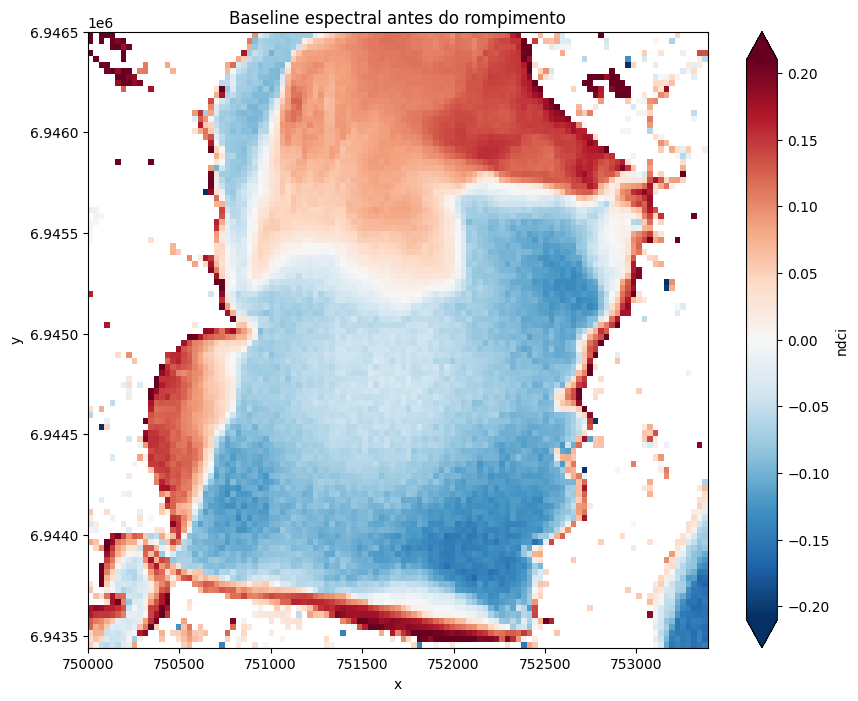

In [16]:
plt.figure(figsize=(10,8))

baseline.plot(
    cmap='RdBu_r',
    vmin=-0.21,
    vmax=0.21
)

plt.title("Baseline espectral antes do rompimento")
plt.show()

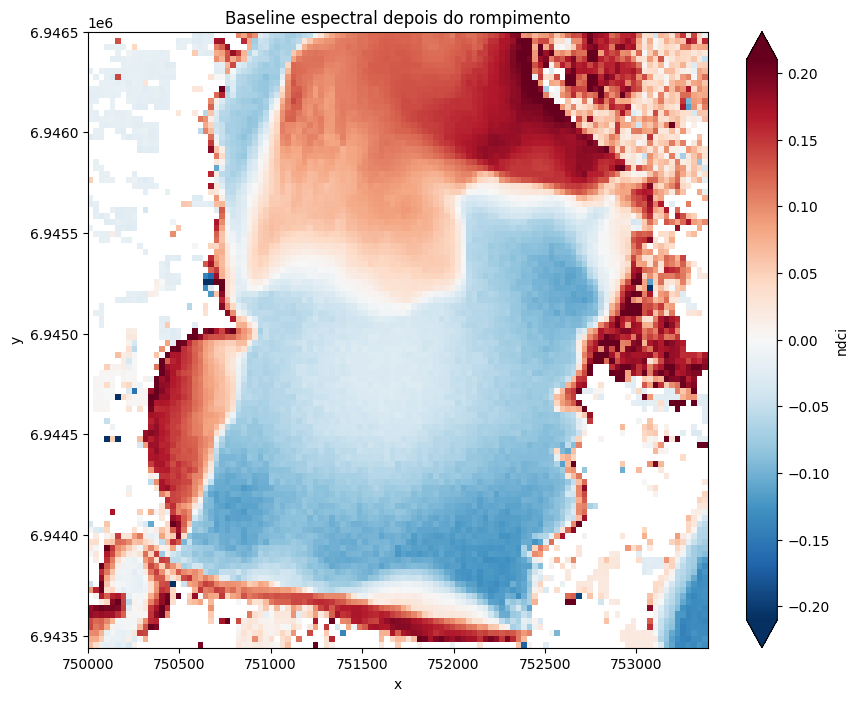

In [17]:
plt.figure(figsize=(10,8))

impact.plot(
    cmap='RdBu_r',
    vmin=-0.21,
    vmax=0.21
)

plt.title("Baseline espectral depois do rompimento")
plt.show()

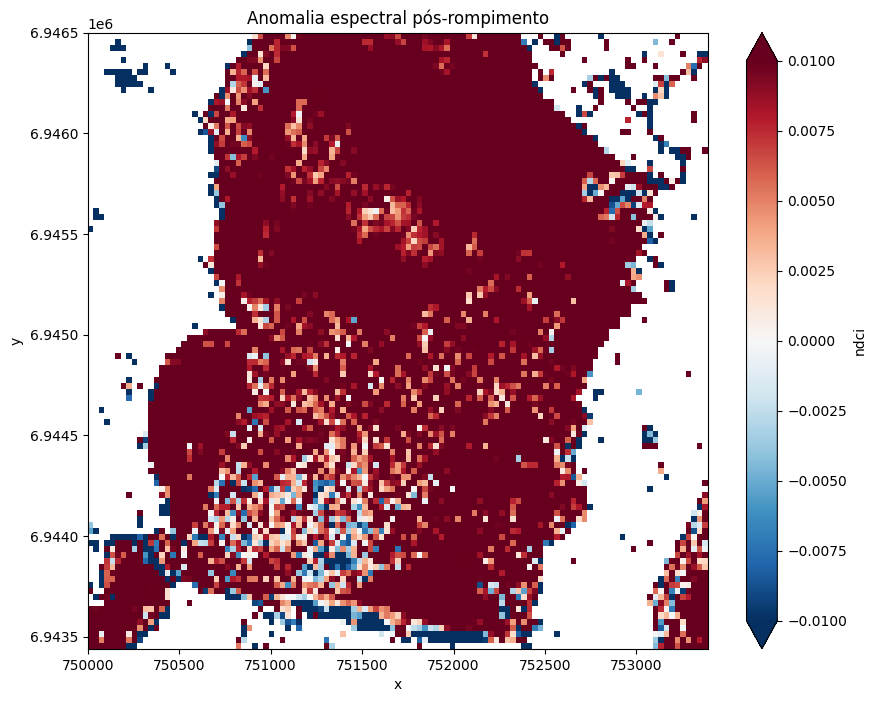

In [18]:
plt.figure(figsize=(10,8))

anomaly.plot(
    cmap='RdBu_r',
    vmin=-0.01,
    vmax=0.01
)

plt.title("Anomalia espectral pós-rompimento")
plt.show()

## Série temporal

/tmp/ipykernel_3190/3532675264.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


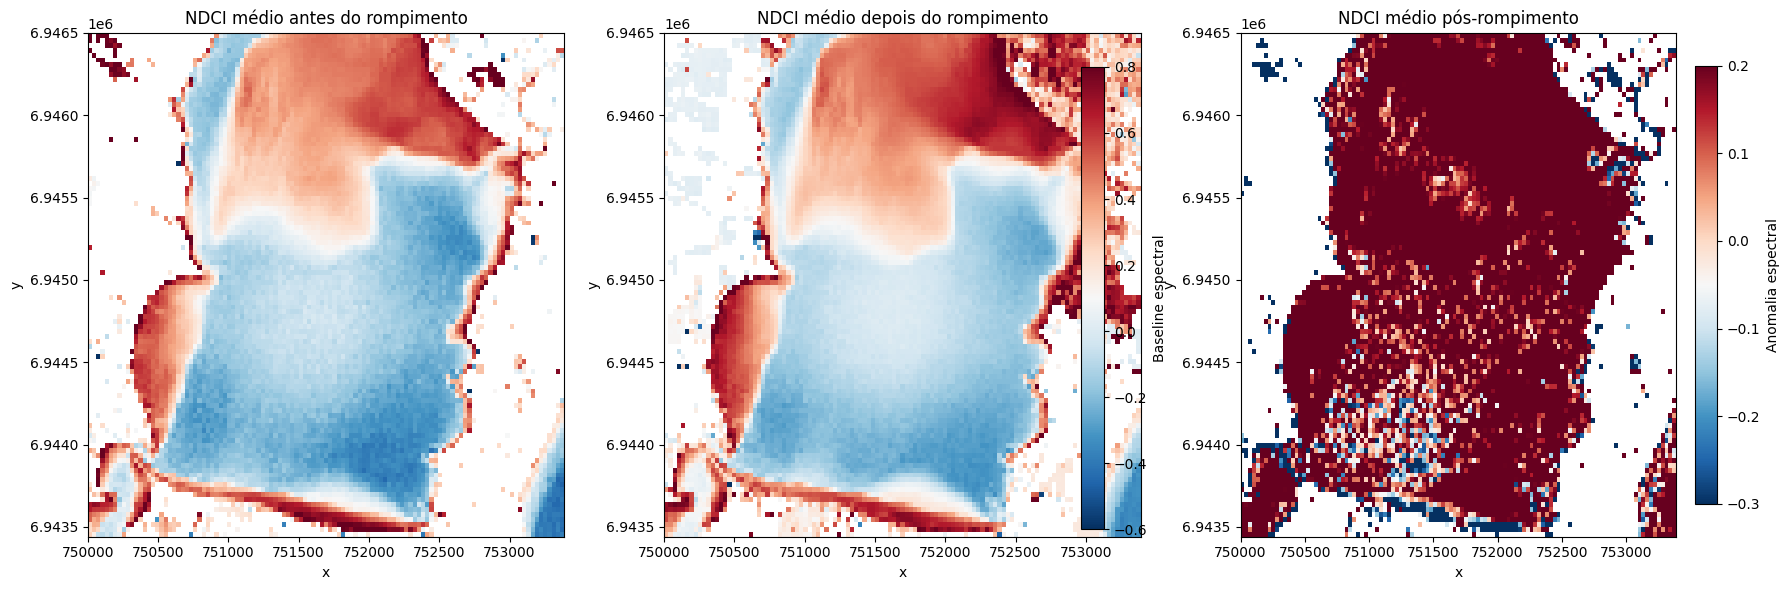

In [19]:
#import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Mapa 1
baseline.plot(
    ax=axes[0],
    cmap='RdBu_r',
    vmin=-0.21,
    vmax=0.21,
    add_colorbar=False
)
axes[0].set_title("NDCI médio antes do rompimento")

# Mapa 2
impact.plot(
    ax=axes[1],
    cmap='RdBu_r',
    vmin=-0.21,
    vmax=0.21,
    add_colorbar=False
)
axes[1].set_title("NDCI médio depois do rompimento")

# Mapa 3
im = anomaly.plot(
    ax=axes[2],
    cmap='RdBu_r',
    vmin=-0.01,
    vmax=0.01,
    add_colorbar=False
)
axes[2].set_title("NDCI médio pós-rompimento")

sm1 = plt.cm.ScalarMappable(
    cmap='RdBu_r',
    norm=plt.Normalize(vmin=-0.6, vmax=0.8)
)
sm1.set_array([])

cbar1 = fig.colorbar(
    sm1,
    ax=[axes[0], axes[1]],
    fraction=0.046,
    pad=0.04
)
cbar1.set_label("Baseline espectral")


sm2 = plt.cm.ScalarMappable(
    cmap='RdBu_r',
    norm=plt.Normalize(vmin=-0.3, vmax=0.2)
)
sm2.set_array([])

cbar2 = fig.colorbar(
    sm2,
    ax=axes[2],
    fraction=0.046,
    pad=0.04
)
cbar2.set_label("Anomalia espectral")

plt.tight_layout()
plt.show()

In [20]:
0.3*0.2

0.06

In [21]:
ts = ds['ndci'].mean(dim=['x', 'y'])

NameError: name 'pd' is not defined

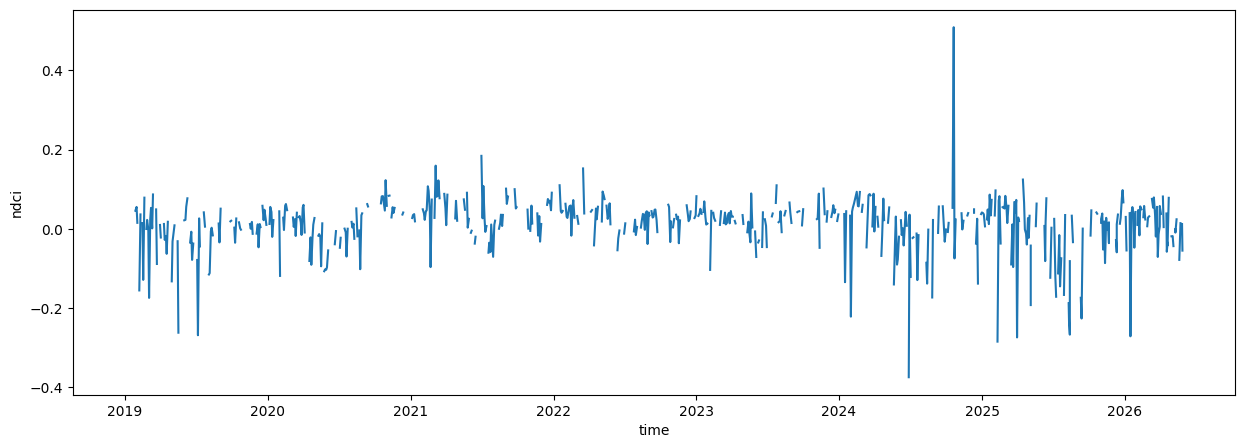

In [22]:
plt.figure(figsize=(15,5))

ts.plot()

plt.axvline(
    pd.to_datetime('2021-01-25'),
    color='red',
    linestyle='--'
)

plt.title("Mudança temporal da reflectância")
plt.show()

In [ ]:
# Série temporal espacial da lagoa
ts = ds['ndci'].mean(dim=['x', 'y'])

# Estatísticas mensais
monthly_mean = ts.resample(time='MS').mean()
monthly_median = ts.resample(time='MS').median()
monthly_std = ts.resample(time='MS').std()

# Criar dataframe
import pandas as pd

df = pd.DataFrame({
    'time': monthly_mean['time'].values,
    'mean': monthly_mean.values,
    'median': monthly_median.values,
    'std': monthly_std.values
})

# Separar ano e mês
df['year'] = pd.to_datetime(df['time']).dt.year
df['month'] = pd.to_datetime(df['time']).dt.month

# Reorganizar colunas
df = df[['year', 'month', 'mean', 'median', 'std']]

print(df)

In [ ]:
df.to_csv('turbidity_monthly_stats.csv', index=False)

In [ ]:
df['date'] = pd.to_datetime(
    dict(
        year=df['year'],
        month=df['month'],
        day=1
    )
)
print(df)

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))

df.boxplot(
    column='mean',
    by='year',
    ax=ax,
    color='blue',
    showfliers=False
)

ax.set_title('Distribuição anual de NDCI')
ax.set_xlabel('Ano')
ax.set_ylabel('NDCI')

plt.suptitle('')
plt.show()

In [ ]:
ts = ds['ndci'].mean(dim=['x', 'y'])

df_raw = ts.to_dataframe().reset_index()

df_raw['year'] = df_raw['time'].dt.year

In [ ]:
df_raw.boxplot(column='ndci', by='year')

In [ ]:
fig, ax = plt.subplots(figsize=(14,5))

ax.plot(
    df['date'],
    df['mean'],
    linewidth=2,
    label='Media'
)

ax.fill_between(
    df['date'],
    df['mean'] - df['std'],
    df['mean'] + df['std'],
    alpha=0.3
)

ax.axvline(
    pd.to_datetime('2021-01-25'),
    linestyle='--',
    label='Rompimento'
)

ax.set_xlabel('Data')
ax.set_ylabel('NDCI')
ax.set_title('Série temporal mensal da lagoa')

ax.legend()

plt.show()

In [ ]:
pip install pymannkendall

In [ ]:
import pymannkendall as mk
import numpy as np

In [ ]:
result = mk.original_test(df['mean'])
print(result)

In [ ]:
#import pymannkendall as mk

# Instalar primeiro: pip install pymannkendall

# Calcular tendência
result = mk.original_test(df['mean'])
slope = result.slope
p_value = result.p
trend = result.trend

# Criar linha de tendência
df['date_numeric'] = (df['date'] - df['date'].min()).dt.days
intercept = np.median(df['mean'] - slope * df['date_numeric'])
trend_line = slope * df['date_numeric'] + intercept

# Plotar (mesmo código anterior)
fig, ax = plt.subplots(figsize=(14,5))
ax.plot(df['date'], df['mean'], linewidth=2, label='Média')
ax.fill_between(df['date'], df['mean'] - df['std'], df['mean'] + df['std'], alpha=0.3)
ax.plot(df['date'], trend_line, 'r--', linewidth=2,
        label=f'Tendência MK (p={p_value:.3f}, slope={slope:.4f})')
ax.axvline(pd.to_datetime('2021-01-25'), linestyle='--', color='gray', label='Rompimento')
ax.set_xlabel('Data')
ax.set_ylabel('NDCI')
ax.set_title('Série temporal mensal da lagoa - com tendência Mann-Kendall')
ax.legend()
plt.show()

print(f"Tendência: {trend}")
print(f"Slope: {slope:.4f}")
print(f"P-valor: {p_value:.4f}")

In [ ]:
#import numpy as np
from scipy import stats
#import pandas as pd
#import matplotlib.pyplot as plt

# Função para calcular tendência de Mann-Kendall e Sen's slope
def mann_kendall_trend(x, y):
    """
    Calcula a tendência de Mann-Kendall e o slope de Sen

    Retorna: slope, intercept, p-value, trend_line
    """
    n = len(x)

    # Calcular slopes entre todos os pares
    slopes = []
    for i in range(n):
        for j in range(i+1, n):
            if x[j] != x[i]:  # Evitar divisão por zero
                slope = (y[j] - y[i]) / (x[j] - x[i])
                slopes.append(slope)

    # Sen's slope é a mediana de todos os slopes
    sen_slope = np.median(slopes)

    # Calcular o intercepto (usando a mediana)
    intercepts = y - sen_slope * x
    intercept = np.median(intercepts)

    # Teste de Mann-Kendall
    tau, p_value = stats.kendalltau(x, y)

    # Gerar linha de tendência
    trend_line = sen_slope * x + intercept

    return sen_slope, intercept, p_value, trend_line

# Converter datas para números (dias desde a primeira data)
df['date_numeric'] = (df['date'] - df['date'].min()).dt.days

# Calcular tendência para toda a série ou para períodos específicos
slope, intercept, p_value, trend_line = mann_kendall_trend(
    df['date_numeric'].values,
    df['mean'].values
)

# Criar o gráfico
fig, ax = plt.subplots(figsize=(14,5))

# Plotar dados originais
ax.plot(df['date'], df['mean'], linewidth=2, label='Média')

# Plotar banda de desvio padrão
ax.fill_between(
    df['date'],
    df['mean'] - df['std'],
    df['mean'] + df['std'],
    alpha=0.3,
    label='±1 Desvio Padrão'
)

# Plotar linha de tendência de Mann-Kendall
ax.plot(df['date'], trend_line, '--', linewidth=2,
        label=f'Tendência Mann-Kendall (p={p_value:.3f}, slope={slope:.4f})')

# Linha vertical de rompimento
ax.axvline(
    pd.to_datetime('2021-01-25'),
    linestyle='--',
    color='gray',
    label='Rompimento'
)

ax.set_xlabel('Data')
ax.set_ylabel('NDCI')
ax.set_title('Série temporal mensal da lagoa')
ax.legend()
plt.show()

# Imprimir resultados
print(f"Sen's slope: {slope:.4f}")
print(f"P-valor: {p_value:.4f}")
if p_value < 0.05:
    print("Tendência estatisticamente significativa (p < 0.05)")
else:
    print("Tendência não estatisticamente significativa (p ≥ 0.05)")

In [23]:
# Separar dados antes e depois do rompimento
data_rompimento = pd.to_datetime('2021-01-25')
df_before = df[df['date'] < data_rompimento].copy()
df_after = df[df['date'] >= data_rompimento].copy()

# Calcular tendências separadas
if len(df_before) > 2:
    slope_before, intercept_before, p_before, trend_before = mann_kendall_trend(
        (df_before['date'] - df_before['date'].min()).dt.days.values,
        df_before['mean'].values
    )
    ax.plot(df_before['date'], trend_before, 'g--', linewidth=1.5,
            label=f'Antes rompimento (p={p_before:.3f})')

if len(df_after) > 2:
    slope_after, intercept_after, p_after, trend_after = mann_kendall_trend(
        (df_after['date'] - df_after['date'].min()).dt.days.values,
        df_after['mean'].values
    )
    ax.plot(df_after['date'], trend_after, 'b--', linewidth=1.5,
            label=f'Depois rompimento (p={p_after:.3f})')

NameError: name 'pd' is not defined

In [ ]:
#import pandas as pd
#import numpy as np
#import matplotlib.pyplot as plt

# Calcular variância móvel (ex: janela de 6 meses)
window_size = 3  # ajuste conforme seus dados
df['variance'] = df['mean'].rolling(window=window_size, min_periods=3).var()
df['std_rolling'] = df['mean'].rolling(window=window_size, min_periods=3).std()

# Plotar
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Gráfico 1: Série original com variância
ax1.plot(df['date'], df['mean'], linewidth=2, label='Média', color='blue')
ax1.fill_between(df['date'],
                 df['mean'] - df['std'],
                 df['mean'] + df['std'],
                 alpha=0.3, label='Desvio padrão original')
ax1.fill_between(df['date'],
                 df['mean'] - df['std_rolling'],
                 df['mean'] + df['std_rolling'],
                 alpha=0.3, label=f'Desvio padrão móvel ({window_size}m)', color='red')
ax1.set_ylabel('NDCI')
ax1.set_title('Série temporal com variabilidade móvel')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfico 2: Variância ao longo do tempo
ax2.plot(df['date'], df['variance'], linewidth=2, color='red', label=f'Variância (janela {window_size}m)')
ax2.axvline(pd.to_datetime('2021-01-25'), linestyle='--', color='gray', label='Rompimento')
ax2.set_xlabel('Data')
ax2.set_ylabel('Variância')
ax2.set_title('Evolução da variância')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()